# Lab 1 - Iris Dataset - EDA + PCA

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

## Load the dataset

In [2]:
# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# Combine for convenience
df = X.copy()
df['species'] = y.iloc[:, 0].values

# Consistent color palette across all plots
species_palette = {
    'Iris-setosa': '#1f77b4',      # blue
    'Iris-versicolor': '#ff7f0e',  # orange
    'Iris-virginica': '#2ca02c'    # green
}

## EDA

### 1. Dataset Overview

In [3]:
# Analyze instances and attributes
print(f"Number of instances (rows): {X.shape[0]}")
print(f"Number of attributes (columns): {X.shape[1]}")
print(f"\nFeature names: {list(X.columns)}")
print(f"\nData types:\n{X.dtypes}")

# Display descriptive statistics of attributes
print("\nDescriptive statistics of attributes:")
display(X.describe())

# Analyze classes and their distribution
print("\nClass distribution in the dataset:")
print(df['species'].value_counts())

Number of instances (rows): 150
Number of attributes (columns): 4

Feature names: ['sepal length', 'sepal width', 'petal length', 'petal width']

Data types:
sepal length    float64
sepal width     float64
petal length    float64
petal width     float64
dtype: object

Descriptive statistics of attributes:


,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Class distribution in the dataset:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### 2. Missing Values

In [4]:
print("Missing values per feature:")
display(X.isnull().sum().rename("Missing Count").to_frame())
print(f"\nTotal missing values: {X.isnull().sum().sum()}")

Missing values per feature:


,Missing Count
sepal length,0
sepal width,0
petal length,0
petal width,0



Total missing values: 0


### 3. Feature Distributions (Histograms + KDE)

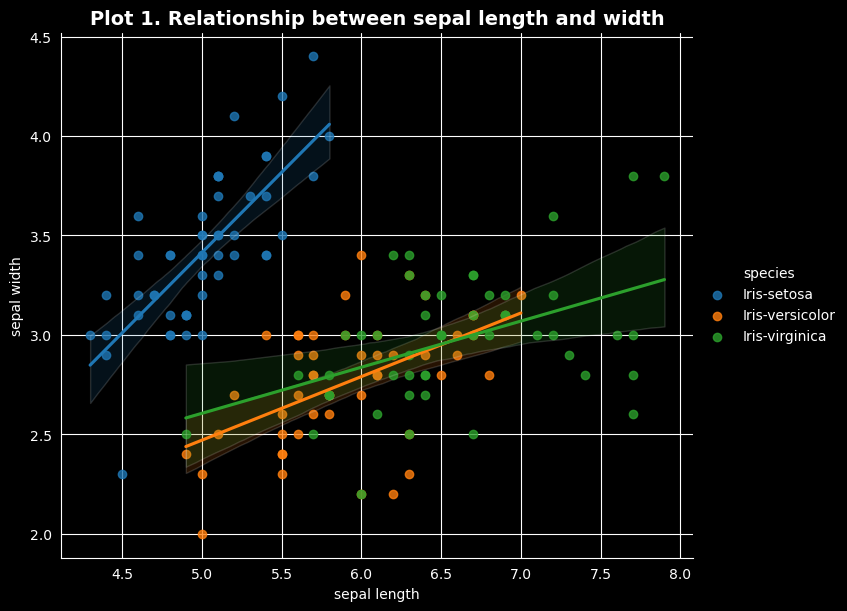

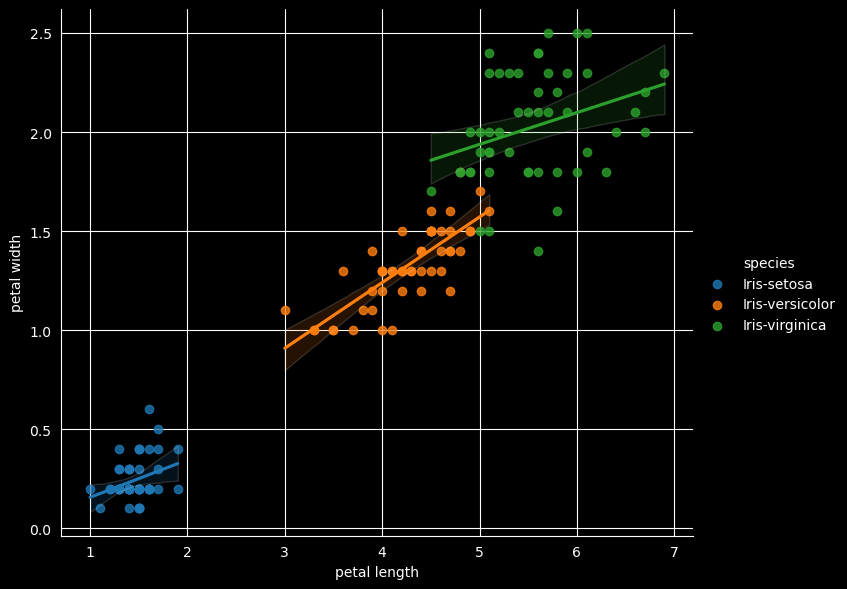

In [25]:
# 5.5 Mandatory Lab Plot 1: Sepal length vs width with regression lines
sns.lmplot(
    data=df,
    x='sepal length',
    y='sepal width',
    hue='species',
    palette=species_palette,
    fit_reg=True,
    height=6,
    aspect=1.2
)
plt.title('Plot 1. Relationship between sepal length and width', fontsize=14, fontweight='bold')
plt.show()

## add a plot for petal length vs width with regression lines
sns.lmplot(
    data=df,
    x='petal length',
    y='petal width',
    hue='species',
    palette=species_palette,
    fit_reg=True,
    height=6,
    aspect=1.2
)

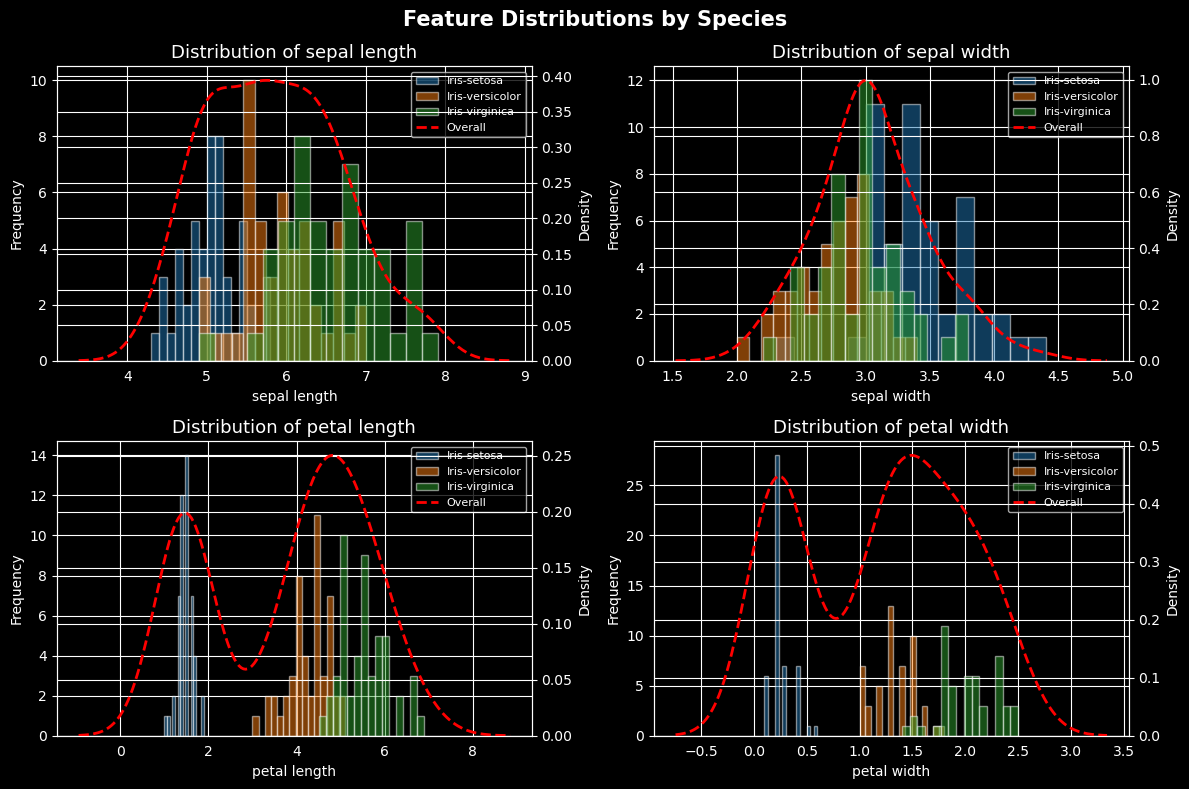

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    for species, group in df.groupby('species'):
        axes[i].hist(group[col], alpha=0.5, label=species, bins=15, edgecolor='white', color=species_palette[species])
    # Overall KDE on a twin axis so it doesn't distort the frequency scale
    ax2 = axes[i].twinx()
    sns.kdeplot(data=df, x=col, ax=ax2, color='red', linewidth=2, linestyle='--', label='Overall')
    ax2.set_ylabel('Density')
    ax2.tick_params(axis='y')
    # Merge legends from both axes
    handles1, labels1 = axes[i].get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    axes[i].legend(handles1 + handles2, labels1 + labels2, fontsize=8)
    axes[i].set_title(f'Distribution of {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Boxplots per Feature by Species

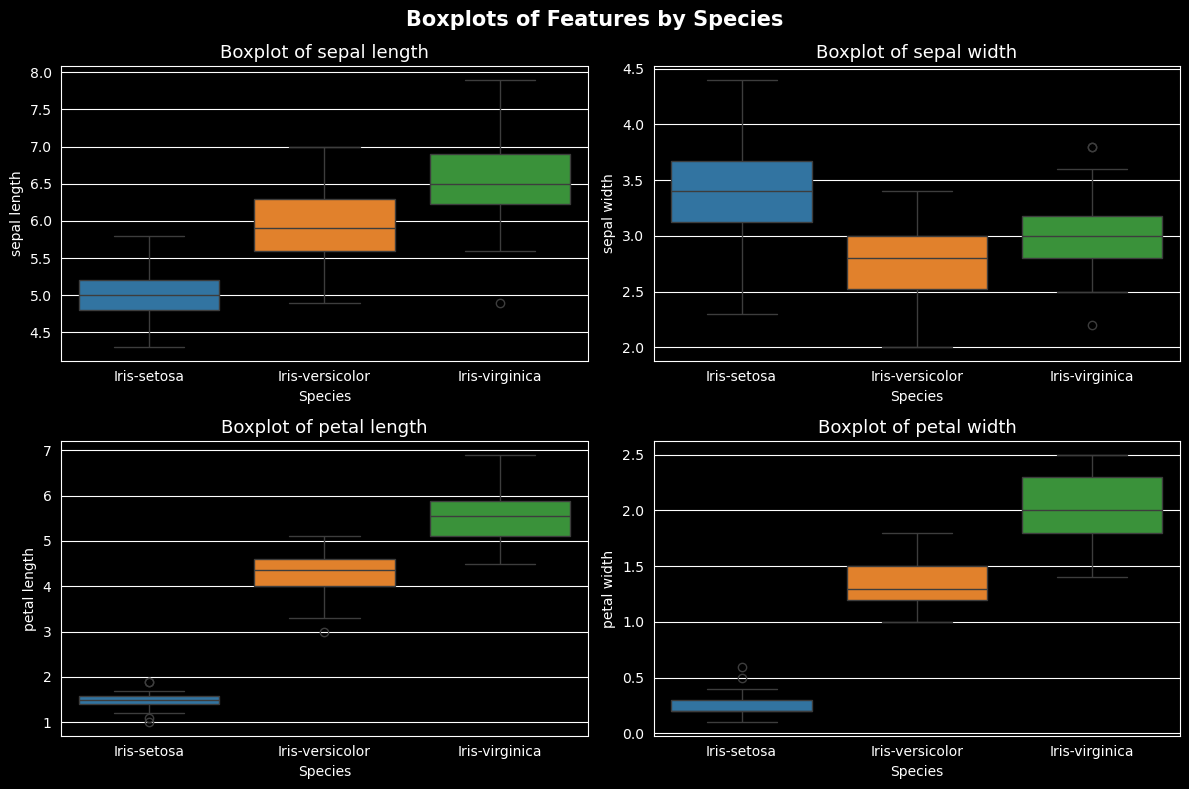

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.boxplot(data=df, x='species', y=col, hue='species', palette=species_palette, legend=False, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=13)
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots of Features by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Violin Plots per Feature by Species

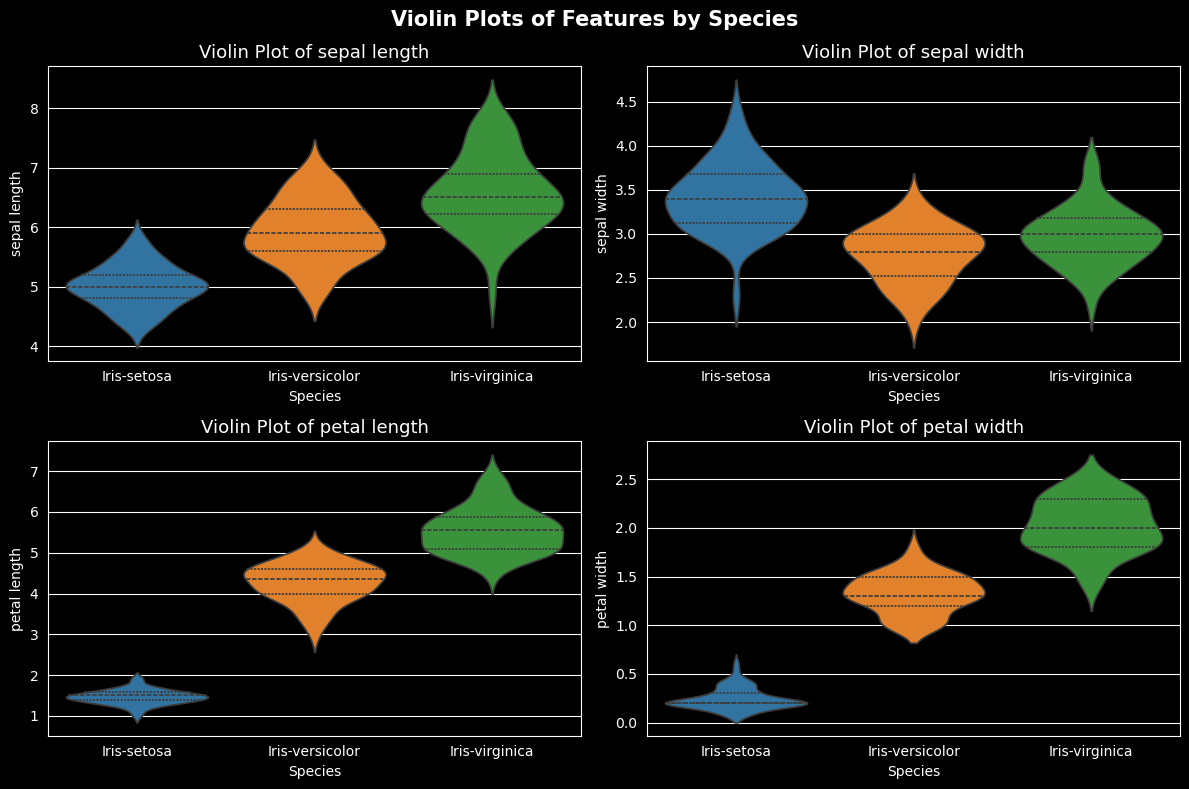

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.violinplot(data=df, x='species', y=col, hue='species', palette=species_palette, inner='quartile', legend=False, ax=axes[i])
    axes[i].set_title(f'Violin Plot of {col}', fontsize=13)
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(col)

plt.suptitle('Violin Plots of Features by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Correlation Heatmap

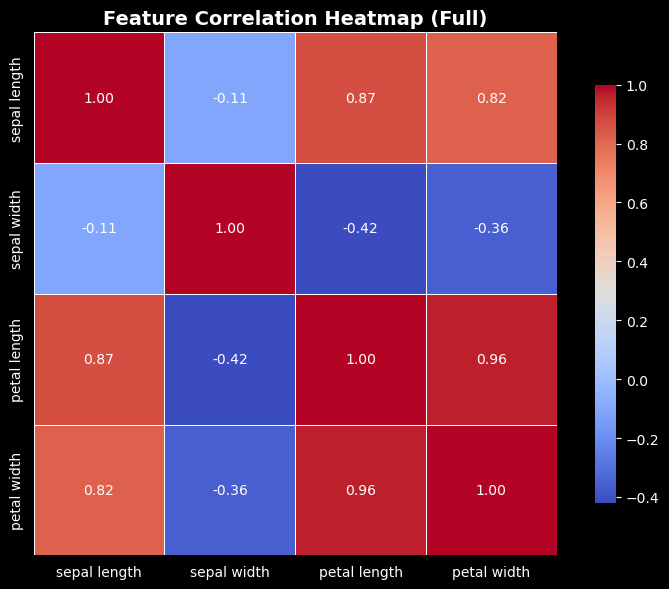

In [21]:
plt.figure(figsize=(8, 6))
corr = X.corr()

# Removed the mask parameter
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap (Full)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Notatki:
- heatmapa wskazuje na negatywną korelację między sepal length a sepal width **na całym zbiorze** - ale gdy rozdzielimy po gatunkach, dla każdego z nich korelacja jest dodatnia (zwłaszcza dla setosa).
-

### 7. PairGrid

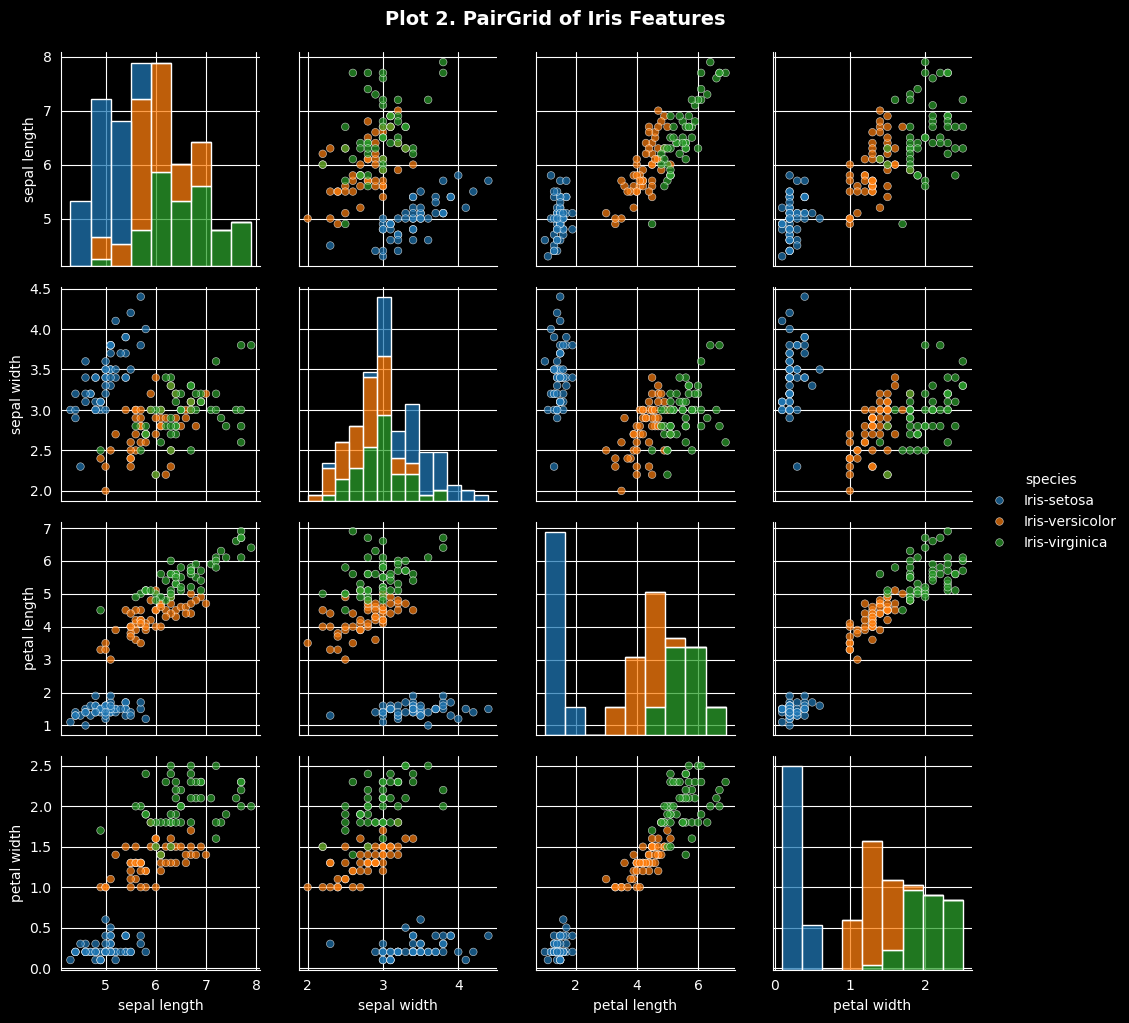

In [27]:
# 7. PairGrid (Lab mandatory Plot 2)
g = sns.PairGrid(df, hue='species', palette=species_palette, diag_sharey=False)

# Match the lab manual: stacked histograms on the diagonal
g.map_diag(sns.histplot, multiple="stack")

# Scatter plots off the diagonal
g.map_offdiag(sns.scatterplot, s=30, alpha=0.7)

g.add_legend()
g.fig.suptitle('Plot 2. PairGrid of Iris Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 8. Summary of Key Findings

In [22]:
print("=== EDA Summary ===\n")
print("• Dataset has 150 samples, 4 features, 3 balanced classes (50 each).")
print("• No missing values found.")
print("\nKey observations:")
for col in X.columns:
    grp_means = df.groupby('species')[col].mean()
    print(f"\n  {col}:")
    for species, mean_val in grp_means.items():
        print(f"    {species}: mean = {mean_val:.2f}")

print("\n• Petal length and petal width show the highest inter-class separation.")
print("• Strong positive correlation between petal length and petal width (r ≈ 0.96).")
print("• Setosa is clearly separable from Versicolor and Virginica on petal features.")
print("• Versicolor and Virginica overlap somewhat — useful for PCA/classification tasks.")


=== EDA Summary ===

• Dataset has 150 samples, 4 features, 3 balanced classes (50 each).
• No missing values found.

Key observations:

  sepal length:
    Iris-setosa: mean = 5.01
    Iris-versicolor: mean = 5.94
    Iris-virginica: mean = 6.59

  sepal width:
    Iris-setosa: mean = 3.42
    Iris-versicolor: mean = 2.77
    Iris-virginica: mean = 2.97

  petal length:
    Iris-setosa: mean = 1.46
    Iris-versicolor: mean = 4.26
    Iris-virginica: mean = 5.55

  petal width:
    Iris-setosa: mean = 0.24
    Iris-versicolor: mean = 1.33
    Iris-virginica: mean = 2.03

• Petal length and petal width show the highest inter-class separation.
• Strong positive correlation between petal length and petal width (r ≈ 0.96).
• Setosa is clearly separable from Versicolor and Virginica on petal features.
• Versicolor and Virginica overlap somewhat — useful for PCA/classification tasks.
